# Quantifying amyloid-β, tau, α-synuclein, and TDP-43 in the Alzheimer hippocampus on annotation-free whole-slide images

This notebook is the analysis for that manuscript. It keeps six pieces:

1. The 87-row footprint-burden table.
2. The match to `abeta_patient_demographics.xlsx`.
3. The unadjusted co-burden Spearman correlations, after exact zeros are set to missing.
4. The burden-adjusted median axis ratio, six pre-specified tests.
5. The burden-adjusted axis-ratio entropy, six pre-specified tests.
6. The stored leave-one-out random forest, which is not refit here.

Single-slide quality control, batch detection, gray–white segmentation, plaque-mixture screens, spatial indices, UMAP, ApoE stratification, and the extra figure gallery are not in this file. They are not the reported tests. Gray–white area is not the burden denominator.

The median and entropy sections read the object files and write the CSV results. Their saved outputs are the manuscript numbers. Running them again repeats the 10,000-resample bootstrap and rewrites those CSV files. If the object files are not on this machine, use the CSV files already stored under `data/`.


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def resolve_data():
    here = Path.cwd().resolve()
    candidates = [
        Path("/nashome/bhavesh/AD-MultiPathology/aBeta-WSI-Analysis-Pipeline/data"),
        here / "data",
        here.parent / "data",
        here / "aBeta-WSI-Analysis-Pipeline" / "data",
        here.parent / "aBeta-WSI-Analysis-Pipeline" / "data",
    ]
    for path in candidates:
        if (path / "multistain_burdens.csv").is_file():
            return path
    raise FileNotFoundError("multistain_burdens.csv was not found")

DATA = resolve_data()
print(f"DATA = {DATA}")

def case_id(value):
    match = re.search(r"(E\d{2}-\d+)", str(value), flags=re.I)
    return match.group(1).upper() if match else pd.NA

def hue_from_rgb(rgb):
    """HSI hue on [0, 1]. rgb is (..., 3) on the unit interval.
    This is the hue used to gate DAB. Object detection is not rerun in this notebook.
    """
    rgb = np.asarray(rgb, dtype=float)
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    eps = 1e-8
    num = 0.5 * ((r - g) + (r - b))
    den = np.sqrt((r - g) ** 2 + (r - b) * (g - b)) + eps
    theta = np.arccos(np.clip(num / den, -1.0, 1.0))
    return np.where(b > g, (2.0 * np.pi - theta), theta) / (2.0 * np.pi)

def area_percent(stained_area, footprint_area):
    """Footprint burden. Not gray-matter normalization."""
    return 100.0 * np.asarray(stained_area, dtype=float) / np.asarray(footprint_area, dtype=float)

print("Axis ratio = minor / major. In the object files the field name is elongation.")
print("A patient summary requires at least 10 finite objects. Primary support requires q < 0.05 and a bootstrap interval that excludes 0.")


DATA = /nashome/bhavesh/AD-MultiPathology/aBeta-WSI-Analysis-Pipeline/data
Axis ratio = minor / major. In the object files the field name is elongation.
A patient summary requires at least 10 finite objects. Primary support requires q < 0.05 and a bootstrap interval that excludes 0.


## Cohort and footprint burden

Burden is `100 × stained object area / slide footprint`. Columns `abeta_pct`, `tau_pct`, `syn_pct`, and `tdp_pct` are those percentages. `Age_death` in the analysis table is the age used for residualization.


Burden rows: 87
Columns: ['patient_id', 'block', 'Braak', 'CERAD', 'Thal', 'abeta_n', 'abeta_pct', 'tau_n', 'tau_pct', 'syn_n', 'syn_pct', 'tdp_n', 'tdp_pct']
Age_death non-missing: 84 of 87; mean 77.79; SD 10.96

Braak non-missing 84
Braak
2.0     1
3.0     5
4.0     5
5.0     8
6.0    65
NaN     3

CERAD non-missing 84
CERAD
2.0     2
3.0    75
5.0     7
NaN     3

Thal non-missing 84
Thal
2.0     1
4.0    14
5.0    69
NaN     3

Footprint area percent
Amyloid-β: n=87 zeros=0 median=0.1606 min=0.0001 max=0.9512
Tau: n=87 zeros=1 median=0.5114 min=0.0000 max=2.9608
α-synuclein: n=87 zeros=5 median=0.0168 min=0.0000 max=3.2009
TDP-43: n=85 zeros=4 median=0.0165 min=0.0000 max=2.0836


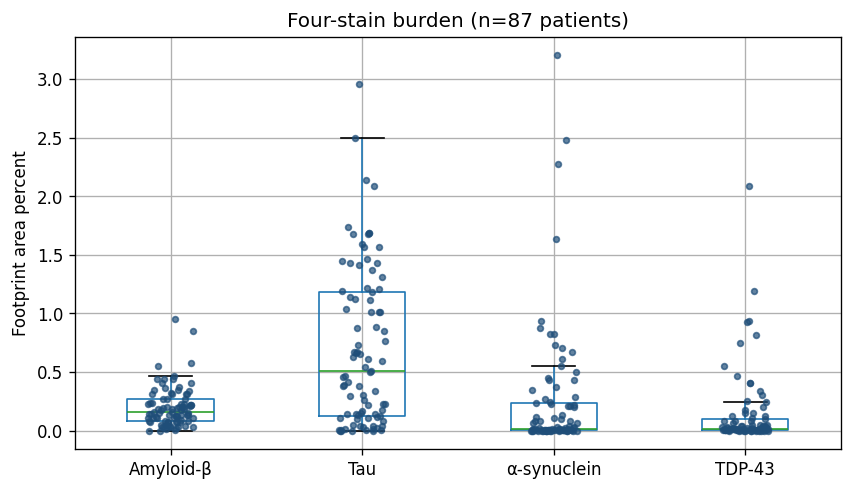

In [4]:
burdens = pd.read_csv(DATA / "multistain_burdens.csv")
analysis = pd.read_csv(DATA / "multistain_analysis_table.csv")
print(f"Burden rows: {len(burdens)}")
print(f"Columns: {list(burdens.columns)}")
age = pd.to_numeric(analysis["Age_death"], errors="coerce")
print(f"Age_death non-missing: {int(age.notna().sum())} of {len(analysis)}; mean {age.mean():.2f}; SD {age.std(ddof=1):.2f}")

for name, col in [("Braak", "Braak"), ("CERAD", "CERAD"), ("Thal", "Thal")]:
    s = pd.to_numeric(burdens[col], errors="coerce")
    counts = s.value_counts(dropna=False).sort_index()
    print(f"\n{name} non-missing {int(s.notna().sum())}")
    print(counts.to_string())

print("\nFootprint area percent")
for col, label in [("abeta_pct", "Amyloid-β"), ("tau_pct", "Tau"), ("syn_pct", "α-synuclein"), ("tdp_pct", "TDP-43")]:
    s = pd.to_numeric(burdens[col], errors="coerce")
    print(f"{label}: n={int(s.notna().sum())} zeros={int((s==0).sum())} median={s.median():.4f} min={s.min():.4f} max={s.max():.4f}")

fig, ax = plt.subplots(figsize=(7.2, 4.2))
plot_df = burdens[["abeta_pct", "tau_pct", "syn_pct", "tdp_pct"]].apply(pd.to_numeric, errors="coerce")
plot_df.columns = ["Amyloid-β", "Tau", "α-synuclein", "TDP-43"]
plot_df.boxplot(ax=ax, showfliers=False)
for i, col in enumerate(plot_df.columns, start=1):
    y = plot_df[col].dropna()
    ax.scatter(np.full(len(y), i) + np.random.default_rng(0).uniform(-0.12, 0.12, len(y)), y, s=12, alpha=0.7, color="#1f4e79", zorder=3)
ax.set_ylabel("Footprint area percent")
ax.set_title(f"Four-stain burden (n={len(burdens)} patients)")
fig.tight_layout()
plt.show()


## Demographics workbook

`abeta_patient_demographics.xlsx` is the bank table. It has no cognitive-test column. A burden row matches a bank row when both contain an identifier of the form `Eyy-nn`. The 233-row bank is not the quantified series.


In [6]:
demo = pd.read_excel(DATA / "abeta_patient_demographics.xlsx", sheet_name="Patient Table")
cog_cols = [c for c in demo.columns if re.search(r"mmse|cdr|cogn", str(c), flags=re.I)]
print(f"Patient Table rows: {len(demo)}")
print("Cognitive columns:", cog_cols if cog_cols else "none")
print(demo["Diagnosis Group"].value_counts().to_string())

ROMAN = {"0": 0, "I": 1, "II": 2, "III": 3, "IV": 4, "V": 5, "VI": 6}

def parse_braak(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().upper().replace("(", "").replace(")", "")
    if text in {"", "NA", "NAN", "NONE"}:
        return np.nan
    if text in ROMAN:
        return float(ROMAN[text])
    try:
        return float(text)
    except ValueError:
        return np.nan

demo = demo.copy()
demo["pid"] = demo["Case Number"].map(case_id)
demo["wb_braak"] = demo["Braak Stage"].map(parse_braak)
demo_u = demo.dropna(subset=["pid"]).drop_duplicates("pid")
linked = burdens.copy()
linked["pid"] = linked["patient_id"].map(case_id)
merged = linked.merge(demo_u, on="pid", how="left", indicator=True)
matched = merged.loc[merged["_merge"].eq("both")].copy()
unmatched = merged.loc[~merged["_merge"].eq("both"), "patient_id"].tolist()
print(f"\nMatched burden rows: {len(matched)} of {len(burdens)}")
print("Unmatched patient_id:", unmatched)
print("Diagnosis Group among matches:")
print(matched["Diagnosis Group"].value_counts(dropna=False).to_string())

matched["age_death"] = pd.to_numeric(matched["Age at Death/Bx"], errors="coerce")
matched["age_onset"] = pd.to_numeric(matched["Age at Onset"], errors="coerce")
matched["duration"] = pd.to_numeric(matched["Duration (years)"], errors="coerce")
for col, label in [("age_death", "Age at death"), ("age_onset", "Age at onset"), ("duration", "Duration")]:
    s = matched[col].dropna()
    print(f"{label}: n={len(s)} mean={s.mean():.2f} SD={s.std(ddof=1):.2f} range={s.min():.0f}–{s.max():.0f}")
print("Sex:")
print(matched["Sex"].value_counts(dropna=False).to_string())
print("Race:")
print(matched["Race"].value_counts(dropna=False).to_string())
print("Family Hx:")
print(matched["Family Hx"].value_counts(dropna=False).to_string())

check = matched.merge(analysis[["patient_id", "Age_death", "Braak"]], on="patient_id", suffixes=("", "_analysis"))
both_age = check[["age_death", "Age_death"]].apply(pd.to_numeric, errors="coerce").dropna()
print(f"Age agreement, both numeric: n={len(both_age)} max abs diff={(both_age['age_death']-both_age['Age_death']).abs().max():.0f}")
both_braak = check[["wb_braak", "Braak_analysis"]].apply(pd.to_numeric, errors="coerce").dropna()
print(f"Braak agreement, both numeric: n={len(both_braak)} max abs diff={(both_braak['wb_braak']-both_braak['Braak_analysis']).abs().max():.0f}")


Patient Table rows: 233
Cognitive columns: none
Diagnosis Group
AD/MCI                 108
LBD                     47
ALS                     25
FTLD-tau/Other FTLD     15
Other/Rare              14
Control                 12
FTLD-TDP                12

Matched burden rows: 83 of 87
Unmatched patient_id: ['OS-240715', 'OS-160608', 'OS_170124', 'OS_170518']
Diagnosis Group among matches:
Diagnosis Group
AD/MCI    83
Age at death: n=83 mean=77.60 SD=10.64 range=54–102
Age at onset: n=82 mean=66.21 SD=10.22 range=48–92
Duration: n=82 mean=11.35 SD=4.34 range=3–26
Sex:
Sex
M    46
F    37
Race:
Race
White             69
Black/AA          13
Hispanic/White     1
Family Hx:
Family Hx
Yes    58
No     25
Age agreement, both numeric: n=80 max abs diff=0
Braak agreement, both numeric: n=80 max abs diff=0


## Co-burden correlations

Exact zeros are set to missing before these Spearman tests. Amyloid-β has no zeros. These three correlations are not inside either shape family and are not multiplicity-adjusted. The same exclusion does not produce an unadjusted association of tau burden with Braak stage.

On the 83 matched patients, the four burdens are also tested against age at death, age at onset, and duration. Those twelve tests are not a cognitive analysis.


In [8]:
def spearman_pair(frame, x, y):
    d = frame[[x, y]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(d) < 5:
        return len(d), np.nan, np.nan
    rho, p = spearmanr(d[x], d[y])
    return len(d), float(rho), float(p)

zeroed = burdens.copy()
for col in ["abeta_pct", "tau_pct", "syn_pct", "tdp_pct"]:
    zeroed[col] = pd.to_numeric(zeroed[col], errors="coerce")
    zeroed.loc[zeroed[col].eq(0), col] = np.nan

print("Co-burden, zeros set to missing")
for x, y, label in [
    ("tau_pct", "CERAD", "Tau burden vs CERAD"),
    ("abeta_pct", "syn_pct", "Amyloid-β burden vs α-synuclein burden"),
    ("syn_pct", "tdp_pct", "α-synuclein burden vs TDP-43 burden"),
    ("tau_pct", "Braak", "Tau burden vs Braak"),
]:
    n, rho, p = spearman_pair(zeroed, x, y)
    print(f"{label}: n={n} rho={rho:.6f} p={p:.6f}")

keep = [c for c in matched.columns if c not in {"abeta_pct", "tau_pct", "syn_pct", "tdp_pct"}]
clin = matched[keep].merge(
    zeroed[["patient_id", "abeta_pct", "tau_pct", "syn_pct", "tdp_pct"]],
    on="patient_id",
    how="left",
)
print("\nBurden vs age at death, onset, and duration on the matched patients")
print("Exact zeros are missing, same rule as the co-burden tests.")
rows = []
for stain in ["abeta_pct", "tau_pct", "syn_pct", "tdp_pct"]:
    for outcome in ["age_death", "age_onset", "duration"]:
        n, rho, p = spearman_pair(clin, stain, outcome)
        rows.append((stain, outcome, n, rho, p))
        print(f"{stain} vs {outcome}: n={n} rho={rho:.6f} p={p:.6f}")
screen = pd.DataFrame(rows, columns=["stain", "outcome", "n", "rho", "p"]).sort_values("p")
print("\nSmallest p in this screen of 12:")
print(screen.head(1).to_string(index=False))


Co-burden, zeros set to missing
Tau burden vs CERAD: n=83 rho=0.230631 p=0.035936
Amyloid-β burden vs α-synuclein burden: n=82 rho=0.318633 p=0.003529
α-synuclein burden vs TDP-43 burden: n=77 rho=0.303412 p=0.007309
Tau burden vs Braak: n=83 rho=0.139341 p=0.208992

Burden vs age at death, onset, and duration on the matched patients
Exact zeros are missing, same rule as the co-burden tests.
abeta_pct vs age_death: n=83 rho=-0.072099 p=0.517159
abeta_pct vs age_onset: n=82 rho=-0.019039 p=0.865186
abeta_pct vs duration: n=82 rho=-0.102755 p=0.358287
tau_pct vs age_death: n=82 rho=-0.042482 p=0.704723
tau_pct vs age_onset: n=81 rho=0.041225 p=0.714800
tau_pct vs duration: n=81 rho=-0.192505 p=0.085113
syn_pct vs age_death: n=78 rho=0.066316 p=0.564032
syn_pct vs age_onset: n=77 rho=0.067765 p=0.558156
syn_pct vs duration: n=77 rho=-0.026718 p=0.817583
tdp_pct vs age_death: n=77 rho=-0.009493 p=0.934695
tdp_pct vs age_onset: n=76 rho=0.016050 p=0.890550
tdp_pct vs duration: n=76 rho=-0.0

## Burden-adjusted median axis ratio

**Question.** Does a patient's median object axis ratio still carry cross-stain information after that stain's own area-percent burden, age at death, and Braak stage are removed?

**Shape measure, fixed before any test.** Axis ratio is the HDF5 column `elongation`, which equals `minor_axis / major_axis` (1 = round). It is not called elongation in the results. For each stain, a patient summary is kept only when at least 10 objects have finite area, eccentricity, and axis ratio. Median and IQR of log(area), eccentricity, and axis ratio are computed. The primary family uses only the median axis ratio. Log(area) is size. Eccentricity is recorded and not tested, so the family stays at six tests. Fractal dimension is not in the files. No saved GMM exists, so there is no morphotype transfer.

**Primary family (six tests).** Rank semi-partial correlation: average-rank the variables, residualize the rank of median axis ratio on the ranks of its own burden, age, and Braak by least squares in rank space, then take the Pearson correlation of that residual with the rank of the outcome. This is not ordinary least squares on the raw measurements; Shapiro-Wilk tests on the patient-level burdens reject normality. The p-value uses a t reference with degrees of freedom n − 2 − k. Bootstrap percentile 95% intervals use 10,000 resamples and seed 42. Benjamini-Hochberg FDR is applied only inside this list.

1. P1. Aβ median axis-ratio residual versus α-synuclein burden, covariates Aβ burden, age, Braak (k=3).
2. P2. α-synuclein median axis-ratio residual versus TDP-43 burden, covariates α-synuclein burden, age, Braak (k=3).
3. P3. Tau median axis-ratio residual versus Aβ burden, covariates tau burden, age, Braak (k=3).
4. P4. Aβ median axis-ratio residual versus tau burden, covariates Aβ burden, age, Braak (k=3).
5. P5. Aβ and α-synuclein median axis-ratio residuals, each residualized on its own burden, age, and Braak (k=4).
6. P6. α-synuclein and TDP-43 median axis-ratio residuals, each residualized on its own burden, age, and Braak (k=4).

**Not in the family.** Spearman correlation of median axis ratio with the same stain's burden is a burden-only comparison. It is plotted and saved, and it is not promoted if the primary family is null.

**Sensitivity, also pre-specified.** Repeat P1–P6 after setting burden values of exactly zero to missing. State n. Do not impute gray-matter area.

**Why this is the gap.** Denning et al. quantified p-tau and pTDP-43 against antemortem MRI (Acta Neuropathol 2024; https://doi.org/10.1007/s00401-024-02789-9). Scalco et al. quantified Aβ classes on 131 temporal-lobe whole-slide images (Acta Neuropathol Commun 2024; https://doi.org/10.1186/s40478-024-01827-7). Wong et al. detected cored plaques and CAA from coarse labels (Commun Biol 2023; https://doi.org/10.1038/s42003-023-05031-6). Colloby et al. mapped regional tau, Aβ, and α-synuclein on tissue-microarray cores (Brain 2025; https://doi.org/10.1093/brain/awae372). Yoshida et al. already measured p-tau, Aβ, α-synuclein, and pTDP-43 area density on hippocampal whole-slide images in 166 cases (Alzheimer's & Dementia 2025; https://doi.org/10.1002/alz.14355). Also opened: Kapasi et al. (J Neuropathol Exp Neurol 2023; https://doi.org/10.1093/jnen/nlad086), Pansuwan et al. (Acta Neuropathol Commun 2023; https://doi.org/10.1186/s40478-023-01674-y), Young et al. (Brain 2023; https://doi.org/10.1093/brain/awad145), Otero-Jimenez et al. (Acta Neuropathol Commun 2025; https://doi.org/10.1186/s40478-025-01944-x), Paterno et al. (Sci Rep 2025; https://doi.org/10.1038/s41598-025-04291-y), and Garcia et al. (J Neuropathol Exp Neurol 2026; https://doi.org/10.1093/jnen/nlaf152). None of those papers residualize the same per-object axis ratio on own burden, age, and Braak and then test another stain. Yoshida et al. already cover four-protein hippocampal whole-slide measurement, so this notebook does not claim priority for that map.

**Hypothesis.** At least one of P1–P6 has BH q < 0.05 and a bootstrap interval that excludes zero. If none do, the result is null.


In [1]:
# S15_EXECUTE
# S15 burden–morphology decoupling. Rank semi-partial Spearman.
# Family is fixed: median axis ratio only. Axis ratio = HDF5 elongation = minor/major.

from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import h5py
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

ROOT = Path("/nashome/bhavesh/AD-MultiPathology")
DATA = ROOT / "aBeta-WSI-Analysis-Pipeline" / "data"
FIG = ROOT / "aBeta-WSI-Analysis-Pipeline" / "figures"
H5_DIRS = [
    ROOT / "aBeta-WSI-Analysis-Pipeline" / "outputs" / "multistain",
    ROOT / "aBeta-WSI-Analysis-Pipeline" / "outputs" / "h5",
]
MIN_N = 10
N_BOOT = 10_000
SEED = 42
RNG = np.random.default_rng(SEED)

for path in [
    DATA / "multistain_burdens.csv",
    DATA / "multistain_analysis_table.csv",
    DATA / "multistain_manifest.csv",
    DATA / "hippocampus_segmentation.csv",
]:
    if not path.is_file():
        raise FileNotFoundError(path)

sns.set_theme(style="whitegrid", context="notebook")
burdens = pd.read_csv(DATA / "multistain_burdens.csv")
analysis = pd.read_csv(DATA / "multistain_analysis_table.csv")
manifest = pd.read_csv(DATA / "multistain_manifest.csv")
seg = pd.read_csv(DATA / "hippocampus_segmentation.csv")

print("=== schemas used ===")
print(f"multistain_burdens n={len(burdens)} columns={list(burdens.columns)}")
print(f"Age_death from multistain_analysis_table non-null={analysis['Age_death'].notna().sum()} of {len(analysis)}")
print(f"hippocampus_segmentation n={len(seg)} methods={seg['segmentation_method'].value_counts().to_dict()}")
print("HDF5 object fields: area, centroid_x, centroid_y, eccentricity, elongation, major_axis, minor_axis, orientation")
print("No perimeter column. No saved GMM parameters. elongation equals minor_axis/major_axis.")

for col in ["Braak", "CERAD", "Thal", "abeta_pct", "tau_pct", "syn_pct", "tdp_pct"]:
    burdens[col] = pd.to_numeric(burdens[col], errors="coerce")
age = analysis[["patient_id", "Age_death"]].drop_duplicates("patient_id")
base = burdens.merge(age, on="patient_id", how="left")
print(f"Joined cohort n={len(base)}")
print(f"Braak non-null={int(base['Braak'].notna().sum())} Age_death non-null={int(base['Age_death'].notna().sum())}")

FILE_COL = {
    "abeta": "abeta_hippo_file",
    "tau": "tau_file",
    "syn": "syn_file",
    "tdp": "tdp_file",
}
BURDEN_COL = {"abeta": "abeta_pct", "tau": "tau_pct", "syn": "syn_pct", "tdp": "tdp_pct"}


def find_h5(fn):
    if not isinstance(fn, str) or not fn.lower().endswith(".svs"):
        return None
    stem = fn[:-4]
    for folder in H5_DIRS:
        path = folder / f"{stem}.h5"
        if path.is_file():
            return path
    return None


manifest["patient_id"] = manifest["patient_id"].astype(str)
base["patient_id"] = base["patient_id"].astype(str)
cohort_ids = set(base["patient_id"])

summaries = []
object_qc = []
for stain, col in FILE_COL.items():
    sub = manifest.loc[manifest["patient_id"].isin(cohort_ids), ["patient_id", col]].drop_duplicates("patient_id")
    n_file = 0
    n_missing_file = 0
    n_nan = 0
    n_inf = 0
    n_objects = 0
    n_below = 0
    for pid, fn in sub.itertuples(index=False):
        path = find_h5(fn) if isinstance(fn, str) else None
        if path is None:
            n_missing_file += 1
            summaries.append({"patient_id": pid, "stain": stain, "n_instances": 0, "n_finite": 0})
            continue
        with h5py.File(path, "r") as handle:
            area = handle["area"][:].astype(np.float64)
            ecc = handle["eccentricity"][:].astype(np.float64)
            elong = handle["elongation"][:].astype(np.float64)
            minor = handle["minor_axis"][:].astype(np.float64)
            major = handle["major_axis"][:].astype(np.float64)
        n = min(len(area), len(ecc), len(elong), len(minor), len(major))
        area, ecc, elong, minor, major = area[:n], ecc[:n], elong[:n], minor[:n], major[:n]
        axis = minor / np.maximum(major, 1e-12)
        n_objects += n
        n_nan += int(np.isnan(area).sum() + np.isnan(ecc).sum() + np.isnan(elong).sum())
        n_inf += int(np.isinf(area).sum() + np.isinf(ecc).sum() + np.isinf(elong).sum())
        finite = np.isfinite(area) & np.isfinite(ecc) & np.isfinite(elong) & np.isfinite(axis) & (area > 0)
        # Confirm stored elongation matches minor/major on this slide.
        if finite.sum() > 0:
            delta = np.max(np.abs(elong[finite] - axis[finite]))
        else:
            delta = np.nan
        n_finite = int(finite.sum())
        n_file += 1
        row = {
            "patient_id": pid,
            "stain": stain,
            "n_instances": n,
            "n_finite": n_finite,
            "axis_matches_elongation_maxabs": float(delta) if np.isfinite(delta) else np.nan,
        }
        if n_finite >= MIN_N:
            aa = area[finite]
            ee = ecc[finite]
            rr = elong[finite]
            loga = np.log(aa)
            row.update(
                {
                    "median_log_area": float(np.median(loga)),
                    "iqr_log_area": float(np.subtract(*np.percentile(loga, [75, 25]))),
                    "median_eccentricity": float(np.median(ee)),
                    "iqr_eccentricity": float(np.subtract(*np.percentile(ee, [75, 25]))),
                    "median_axis_ratio": float(np.median(rr)),
                    "iqr_axis_ratio": float(np.subtract(*np.percentile(rr, [75, 25]))),
                }
            )
        else:
            n_below += 1
        summaries.append(row)
    object_qc.append(
        {
            "stain": stain,
            "files_read": n_file,
            "missing_file": n_missing_file,
            "n_objects": n_objects,
            "n_nan_values": n_nan,
            "n_inf_values": n_inf,
            "patients_below_min_instances": n_below,
        }
    )
    print(
        f"  {stain}: files={n_file} missing_file={n_missing_file} objects={n_objects} "
        f"nan_values={n_nan} inf_values={n_inf} patients_n_finite<{MIN_N}={n_below}"
    )

qc = pd.DataFrame(object_qc)
feat = pd.DataFrame(summaries)
print(f"Axis-ratio vs minor/major max abs deviation: {feat['axis_matches_elongation_maxabs'].max()}")
wide = feat.pivot(index="patient_id", columns="stain")
wide.columns = [f"{b}_{a}" for a, b in wide.columns]
wide = wide.reset_index()
patient = base.merge(wide, on="patient_id", how="left")
print(f"Patient table n={len(patient)} median_axis_ratio non-null:")
for stain in FILE_COL:
    col = f"{stain}_median_axis_ratio"
    print(f"  {stain} {int(patient[col].notna().sum())}")

# Shapiro-Wilk on patient-level summaries, to document why raw OLS is not used.
print("=== Shapiro-Wilk on patient-level median axis ratio and burden ===")
shapiro_rows = []
for stain in FILE_COL:
    for label, col in (
        ("median_axis_ratio", f"{stain}_median_axis_ratio"),
        ("burden_pct", BURDEN_COL[stain]),
    ):
        x = patient[col].dropna().to_numpy()
        if len(x) < 3 or len(x) > 5000:
            w, p = np.nan, np.nan
        else:
            w, p = stats.shapiro(x)
        print(f"  {stain} {label}: n={len(x)} W={w:.6f} p={p:.6g}")
        shapiro_rows.append({"stain": stain, "variable": label, "n": len(x), "W": w, "p": p})


def complete(frame, cols):
    before = len(frame)
    out = frame.dropna(subset=cols).copy()
    print(f"    complete {cols}: n_in={before} n_out={len(out)} dropped={before - len(out)}")
    return out


def semi_partial(frame, y_col, outcome_col, cov_cols):
    """Rank semi-partial correlation: residualize rank(y) on rank(covariates), Pearson with rank(outcome)."""
    cols = [y_col, outcome_col] + list(cov_cols)
    d = frame[cols].dropna()
    n = len(d)
    k = len(cov_cols)
    if n < k + 5:
        return n, np.nan, np.nan, k, None
    ranks = d.rank(method="average")
    y = ranks[y_col].to_numpy()
    outcome = ranks[outcome_col].to_numpy()
    Z = np.column_stack([np.ones(n)] + [ranks[c].to_numpy() for c in cov_cols])
    beta = np.linalg.lstsq(Z, y, rcond=None)[0]
    resid = y - Z @ beta
    if np.std(resid) < 1e-12 or np.std(outcome) < 1e-12:
        return n, np.nan, np.nan, k, None
    rho = float(np.corrcoef(resid, outcome)[0, 1])
    dof = n - 2 - k
    if dof <= 0 or not np.isfinite(rho) or abs(rho) >= 1:
        p = np.nan
    else:
        tstat = rho * np.sqrt(dof / (1.0 - rho * rho))
        p = float(2 * stats.t.sf(abs(tstat), dof))
    return n, rho, p, k, dof


def semi_partial_shape_shape(frame, y_a, cov_a, y_b, cov_b, k_union):
    cols = [y_a, y_b] + list(dict.fromkeys(list(cov_a) + list(cov_b)))
    d = frame[cols].dropna()
    n = len(d)
    if n < k_union + 5:
        return n, np.nan, np.nan, k_union, None
    ranks = d.rank(method="average")

    def resid(y_col, covs):
        y = ranks[y_col].to_numpy()
        Z = np.column_stack([np.ones(n)] + [ranks[c].to_numpy() for c in covs])
        beta = np.linalg.lstsq(Z, y, rcond=None)[0]
        return y - Z @ beta

    ra = resid(y_a, cov_a)
    rb = resid(y_b, cov_b)
    if np.std(ra) < 1e-12 or np.std(rb) < 1e-12:
        return n, np.nan, np.nan, k_union, None
    rho = float(np.corrcoef(ra, rb)[0, 1])
    dof = n - 2 - k_union
    if dof <= 0 or not np.isfinite(rho) or abs(rho) >= 1:
        p = np.nan
    else:
        tstat = rho * np.sqrt(dof / (1.0 - rho * rho))
        p = float(2 * stats.t.sf(abs(tstat), dof))
    return n, rho, p, k_union, dof


def boot_semi(frame, kind, spec):
    cols = spec["cols"]
    d = frame[cols].dropna().reset_index(drop=True)
    n = len(d)
    if n < 8:
        return np.nan, np.nan, 0
    values = d.to_numpy()
    draws = np.empty(N_BOOT)
    for i in range(N_BOOT):
        take = RNG.choice(n, n, replace=True)
        sub = pd.DataFrame(values[take], columns=cols)
        if kind == "one":
            _, rho, _, _, _ = semi_partial(sub, spec["y"], spec["outcome"], spec["cov"])
        else:
            _, rho, _, _, _ = semi_partial_shape_shape(
                sub, spec["y_a"], spec["cov_a"], spec["y_b"], spec["cov_b"], spec["k"]
            )
        draws[i] = rho
    ok = draws[np.isfinite(draws)]
    if len(ok) < 100:
        return np.nan, np.nan, int(len(ok))
    lo, hi = np.percentile(ok, [2.5, 97.5])
    return float(lo), float(hi), int(len(ok))


def boot_spearman(frame, x, y):
    d = frame[[x, y]].dropna()
    n = len(d)
    if n < 5:
        return np.nan, np.nan, 0
    xv = d[x].to_numpy()
    yv = d[y].to_numpy()
    draws = np.empty(N_BOOT)
    for i in range(N_BOOT):
        take = RNG.choice(n, n, replace=True)
        rx = pd.Series(xv[take]).rank(method="average").to_numpy()
        ry = pd.Series(yv[take]).rank(method="average").to_numpy()
        rx = rx - rx.mean()
        ry = ry - ry.mean()
        denom = np.sqrt(np.dot(rx, rx) * np.dot(ry, ry))
        draws[i] = np.nan if denom == 0 else float(np.dot(rx, ry) / denom)
    ok = draws[np.isfinite(draws)]
    if len(ok) < 100:
        return np.nan, np.nan, int(len(ok))
    lo, hi = np.percentile(ok, [2.5, 97.5])
    return float(lo), float(hi), int(len(ok))


# Pre-specified primary family. Do not add tests after seeing p.
PRIMARY = [
    {
        "test_id": "P1",
        "kind": "one",
        "label": "Aβ axis-ratio residual → α-synuclein burden",
        "y": "abeta_median_axis_ratio",
        "outcome": "syn_pct",
        "cov": ["abeta_pct", "Age_death", "Braak"],
        "k": 3,
    },
    {
        "test_id": "P2",
        "kind": "one",
        "label": "α-synuclein axis-ratio residual → TDP-43 burden",
        "y": "syn_median_axis_ratio",
        "outcome": "tdp_pct",
        "cov": ["syn_pct", "Age_death", "Braak"],
        "k": 3,
    },
    {
        "test_id": "P3",
        "kind": "one",
        "label": "tau axis-ratio residual → Aβ burden",
        "y": "tau_median_axis_ratio",
        "outcome": "abeta_pct",
        "cov": ["tau_pct", "Age_death", "Braak"],
        "k": 3,
    },
    {
        "test_id": "P4",
        "kind": "one",
        "label": "Aβ axis-ratio residual → tau burden",
        "y": "abeta_median_axis_ratio",
        "outcome": "tau_pct",
        "cov": ["abeta_pct", "Age_death", "Braak"],
        "k": 3,
    },
    {
        "test_id": "P5",
        "kind": "shape",
        "label": "Aβ axis-ratio residual ↔ α-synuclein axis-ratio residual",
        "y_a": "abeta_median_axis_ratio",
        "cov_a": ["abeta_pct", "Age_death", "Braak"],
        "y_b": "syn_median_axis_ratio",
        "cov_b": ["syn_pct", "Age_death", "Braak"],
        "k": 4,
    },
    {
        "test_id": "P6",
        "kind": "shape",
        "label": "α-synuclein axis-ratio residual ↔ TDP-43 axis-ratio residual",
        "y_a": "syn_median_axis_ratio",
        "cov_a": ["syn_pct", "Age_death", "Braak"],
        "y_b": "tdp_median_axis_ratio",
        "cov_b": ["tdp_pct", "Age_death", "Braak"],
        "k": 4,
    },
]
for spec in PRIMARY:
    if spec["kind"] == "one":
        spec["cols"] = [spec["y"], spec["outcome"]] + spec["cov"]
    else:
        spec["cols"] = list(dict.fromkeys([spec["y_a"], spec["y_b"]] + spec["cov_a"] + spec["cov_b"]))


def run_family(frame, role):
    rows = []
    print(f"=== {role} family n_patients_in_frame={len(frame)} ===")
    for spec in PRIMARY:
        if spec["kind"] == "one":
            n, rho, p, k, dof = semi_partial(frame, spec["y"], spec["outcome"], spec["cov"])
        else:
            n, rho, p, k, dof = semi_partial_shape_shape(
                frame, spec["y_a"], spec["cov_a"], spec["y_b"], spec["cov_b"], spec["k"]
            )
        lo, hi, n_ok = boot_semi(frame, spec["kind"], spec)
        print(
            f"  {spec['test_id']} {spec['label']}: n={n} rho={rho:+.6f} p={p:.6g} "
            f"CI=[{lo:+.6f}, {hi:+.6f}] boot_ok={n_ok} df={dof}"
        )
        rows.append(
            {
                "role": role,
                "test_id": spec["test_id"],
                "test": spec["label"],
                "n": n,
                "rho": rho,
                "p": p,
                "df": dof,
                "k_covariates": k,
                "ci95_low": lo,
                "ci95_high": hi,
                "bootstrap_resamples": n_ok,
                "method": "rank semi-partial Pearson of residualized ranks",
                "shape": "median axis ratio (minor/major; HDF5 column elongation)",
                "min_instances": MIN_N,
                "seed": SEED,
            }
        )
    pvals = [r["p"] for r in rows]
    if np.all(np.isfinite(pvals)):
        _, qvals, _, _ = multipletests(pvals, method="fdr_bh")
    else:
        qvals = [np.nan] * len(rows)
    for r, q in zip(rows, qvals):
        r["q_bh"] = float(q)
        print(f"    BH-FDR {r['test_id']}: q={q:.6g}")
    return pd.DataFrame(rows)


=== schemas used ===
multistain_burdens n=87 columns=['patient_id', 'block', 'Braak', 'CERAD', 'Thal', 'abeta_n', 'abeta_pct', 'tau_n', 'tau_pct', 'syn_n', 'syn_pct', 'tdp_n', 'tdp_pct']
Age_death from multistain_analysis_table non-null=84 of 87
hippocampus_segmentation n=65 methods={'heuristic_fallback': 65}
HDF5 object fields: area, centroid_x, centroid_y, eccentricity, elongation, major_axis, minor_axis, orientation
No perimeter column. No saved GMM parameters. elongation equals minor_axis/major_axis.
Joined cohort n=87
Braak non-null=84 Age_death non-null=84
  abeta: files=87 missing_file=0 objects=562824 nan_values=0 inf_values=0 patients_n_finite<10=1
  tau: files=87 missing_file=0 objects=803940 nan_values=0 inf_values=0 patients_n_finite<10=3
  syn: files=87 missing_file=0 objects=359447 nan_values=0 inf_values=0 patients_n_finite<10=6
  tdp: files=85 missing_file=2 objects=268333 nan_values=0 inf_values=0 patients_n_finite<10=6
Axis-ratio vs minor/major max abs deviation: 1.27

In [2]:
# S15_EXECUTE
print("\n=== primary tests ===")
primary = run_family(patient, "primary")
primary_path = DATA / "s15_primary_analysis.csv"
primary.to_csv(primary_path, index=False)
print(f"Wrote {primary_path}")



=== primary tests ===
=== primary family n_patients_in_frame=87 ===
  P1 Aβ axis-ratio residual → α-synuclein burden: n=83 rho=-0.188198 p=0.0945681 CI=[-0.392865, +0.038168] boot_ok=10000 df=78
  P2 α-synuclein axis-ratio residual → TDP-43 burden: n=76 rho=-0.228086 p=0.0522833 CI=[-0.400005, -0.017621] boot_ok=10000 df=71
  P3 tau axis-ratio residual → Aβ burden: n=81 rho=+0.144572 p=0.206641 CI=[-0.090209, +0.378029] boot_ok=10000 df=76
  P4 Aβ axis-ratio residual → tau burden: n=83 rho=+0.090148 p=0.426477 CI=[-0.130784, +0.303854] boot_ok=10000 df=78
  P5 Aβ axis-ratio residual ↔ α-synuclein axis-ratio residual: n=78 rho=+0.155384 p=0.186185 CI=[-0.026254, +0.320251] boot_ok=10000 df=72
  P6 α-synuclein axis-ratio residual ↔ TDP-43 axis-ratio residual: n=72 rho=-0.024457 p=0.843072 CI=[-0.207585, +0.192671] boot_ok=10000 df=66
    BH-FDR P1: q=0.283704
    BH-FDR P2: q=0.283704
    BH-FDR P3: q=0.309961
    BH-FDR P4: q=0.511772
    BH-FDR P5: q=0.309961
    BH-FDR P6: q=0.843072

In [3]:
# S15_EXECUTE
print("\n=== sensitivity: zero burdens set to missing ===")
sens_frame = patient.copy()
n_zero = {}
for stain, col in BURDEN_COL.items():
    n_zero[stain] = int((sens_frame[col] == 0).sum())
    sens_frame.loc[sens_frame[col] == 0, col] = np.nan
print(f"Zero burdens set to missing: {n_zero}")
sensitivity = run_family(sens_frame, "sensitivity_zero_as_missing")
sens_path = DATA / "s15_sensitivity.csv"
sensitivity.to_csv(sens_path, index=False)
print(f"Wrote {sens_path}")



=== sensitivity: zero burdens set to missing ===
Zero burdens set to missing: {'abeta': 0, 'tau': 1, 'syn': 5, 'tdp': 4}
=== sensitivity_zero_as_missing family n_patients_in_frame=87 ===
  P1 Aβ axis-ratio residual → α-synuclein burden: n=79 rho=-0.299878 p=0.00849299 CI=[-0.485413, -0.076569] boot_ok=10000 df=74
  P2 α-synuclein axis-ratio residual → TDP-43 burden: n=74 rho=-0.260575 p=0.0281825 CI=[-0.432519, -0.028771] boot_ok=10000 df=69
  P3 tau axis-ratio residual → Aβ burden: n=81 rho=+0.144572 p=0.206641 CI=[-0.095336, +0.369875] boot_ok=10000 df=76
  P4 Aβ axis-ratio residual → tau burden: n=82 rho=+0.078047 p=0.494175 CI=[-0.147776, +0.293414] boot_ok=10000 df=77
  P5 Aβ axis-ratio residual ↔ α-synuclein axis-ratio residual: n=78 rho=+0.155384 p=0.186185 CI=[-0.022451, +0.322336] boot_ok=10000 df=72
  P6 α-synuclein axis-ratio residual ↔ TDP-43 axis-ratio residual: n=72 rho=-0.024457 p=0.843072 CI=[-0.210355, +0.190406] boot_ok=10000 df=66
    BH-FDR P1: q=0.0509579
    BH-F

In [4]:
# S15_EXECUTE
print("\n=== validation: median axis ratio vs own burden (not in the primary family) ===")
val_rows = []
for stain, bcol in BURDEN_COL.items():
    x = f"{stain}_median_axis_ratio"
    d = patient[[x, bcol]].dropna()
    n = len(d)
    if n >= 5:
        rho, p = stats.spearmanr(d[x], d[bcol])
        rho, p = float(rho), float(p)
    else:
        rho, p = np.nan, np.nan
    lo, hi, n_ok = boot_spearman(patient, x, bcol)
    print(f"  {stain} axis ratio vs own burden: n={n} rho={rho:+.6f} p={p:.6g} CI=[{lo:+.6f}, {hi:+.6f}]")
    qc_row = qc.loc[qc["stain"] == stain].iloc[0]
    shap = next(s for s in shapiro_rows if s["stain"] == stain and s["variable"] == "median_axis_ratio")
    shb = next(s for s in shapiro_rows if s["stain"] == stain and s["variable"] == "burden_pct")
    val_rows.append(
        {
            "record": "burden_only_spearman",
            "stain": stain,
            "n": n,
            "rho": rho,
            "p": p,
            "q_bh": np.nan,
            "ci95_low": lo,
            "ci95_high": hi,
            "bootstrap_resamples": n_ok,
            "files_read": int(qc_row["files_read"]),
            "missing_file": int(qc_row["missing_file"]),
            "n_objects": int(qc_row["n_objects"]),
            "n_nan_values": int(qc_row["n_nan_values"]),
            "n_inf_values": int(qc_row["n_inf_values"]),
            "patients_below_min_instances": int(qc_row["patients_below_min_instances"]),
            "shapiro_axis_ratio_p": shap["p"],
            "shapiro_burden_p": shb["p"],
            "in_primary_family": False,
            "note": "exploratory quantity-vs-shape association; not FDR-adjusted; not the primary test",
        }
    )
val = pd.DataFrame(val_rows)
val_path = DATA / "s15_validation.csv"
val.to_csv(val_path, index=False)
print(f"Wrote {val_path}")
print(
    "Gray matter: hippocampus_segmentation.csv is Aβ-only "
    f"(rows={len(seg)}, method={seg['segmentation_method'].unique().tolist()}). "
    "Multi-stain burden stays footprint-normalized. Gray-matter area was not imputed."
)

print("\n=== figure ===")
fig, axes = plt.subplots(1, 2, figsize=(12.2, 6.2), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
order = primary.reset_index(drop=True)
yy = np.arange(len(order))[::-1]
ax.errorbar(
    order["rho"],
    yy,
    xerr=[order["rho"] - order["ci95_low"], order["ci95_high"] - order["rho"]],
    fmt="o",
    color="#1f4e79",
    capsize=3,
    markersize=6,
)
ax.axvline(0, color="0.45", lw=0.8)
ax.set_yticks(yy)
ax.set_yticklabels(
    [
        "P1  Aβ shape residual → syn burden",
        "P2  syn shape residual → TDP-43 burden",
        "P3  tau shape residual → Aβ burden",
        "P4  Aβ shape residual → tau burden",
        "P5  Aβ shape residual ↔ syn shape residual",
        "P6  syn shape residual ↔ TDP-43 shape residual",
    ]
)
ax.set_xlabel("Rank semi-partial ρ (95% bootstrap CI)")
ax.set_title("Primary family (BH-FDR across these 6)")
ax = axes[1]
yy = np.arange(len(val))[::-1]
ax.errorbar(
    val["rho"],
    yy,
    xerr=[val["rho"] - val["ci95_low"], val["ci95_high"] - val["rho"]],
    fmt="o",
    color="#b85c38",
    capsize=3,
    markersize=6,
)
ax.axvline(0, color="0.45", lw=0.8)
ax.set_yticks(yy)
ax.set_yticklabels([f"{s}  n={int(n)}" for s, n in zip(val["stain"], val["n"])])
ax.set_xlabel("Spearman ρ (95% bootstrap CI)")
ax.set_title("Burden-only comparison\n(not in the primary family)")

fig.suptitle(
    "Does median axis ratio still carry cross-stain information\n"
    "after own burden, age, and Braak are removed?\n"
    "Axis ratio = minor / major (HDF5 field 'elongation'; 1 = round)",
    fontsize=12,
)
fig.tight_layout()
fig_path = FIG / "fig_s15_novel_contribution.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.close(fig)
print(f"Wrote {fig_path} bytes={fig_path.stat().st_size}")
survives = primary.loc[(primary["q_bh"] < 0.05) & (primary["ci95_low"] * primary["ci95_high"] > 0)]
print(f"Primary tests with q<0.05 and CI excluding 0: n={len(survives)}")
if len(survives) == 0:
    print("PRIMARY RESULT: null. Median object axis ratio did not explain cross-pathology burden associations after adjustment for own-stain burden, age, and Braak stage.")
else:
    print("PRIMARY RESULT: the following pre-specified tests survive:")
    print(survives[["test_id", "n", "rho", "p", "q_bh", "ci95_low", "ci95_high"]].to_string(index=False))
print("S15 finished")



=== validation: median axis ratio vs own burden (not in the primary family) ===
  abeta axis ratio vs own burden: n=86 rho=+0.161923 p=0.13636 CI=[-0.083490, +0.388572]
  tau axis ratio vs own burden: n=84 rho=+0.660720 p=7.98521e-12 CI=[+0.480531, +0.789700]
  syn axis ratio vs own burden: n=81 rho=+0.645962 p=7.41992e-11 CI=[+0.429253, +0.829846]
  tdp axis ratio vs own burden: n=79 rho=+0.742047 p=5.10013e-15 CI=[+0.587724, +0.851415]
Wrote /nashome/bhavesh/AD-MultiPathology/aBeta-WSI-Analysis-Pipeline/data/s15_validation.csv
Gray matter: hippocampus_segmentation.csv is Aβ-only (rows=65, method=['heuristic_fallback']). Multi-stain burden stays footprint-normalized. Gray-matter area was not imputed.

=== figure ===
Wrote /nashome/bhavesh/AD-MultiPathology/aBeta-WSI-Analysis-Pipeline/figures/fig_s15_novel_contribution.png bytes=203867
Primary tests with q<0.05 and CI excluding 0: n=0
PRIMARY RESULT: null. Median object axis ratio did not explain cross-pathology burden associations af

In [5]:
# S15_EXECUTE
print("=== results table: primary ===")
print(primary.to_string(index=False))
print("=== results table: sensitivity ===")
print(sensitivity.to_string(index=False))
print("=== results table: burden-only comparison, not in the primary family ===")
print(val.to_string(index=False))


=== results table: primary ===
   role test_id                                                         test  n       rho        p  df  k_covariates  ci95_low  ci95_high  bootstrap_resamples                                          method                                                   shape  min_instances  seed     q_bh
primary      P1                  Aβ axis-ratio residual → α-synuclein burden 83 -0.188198 0.094568  78             3 -0.392865   0.038168                10000 rank semi-partial Pearson of residualized ranks median axis ratio (minor/major; HDF5 column elongation)             10    42 0.283704
primary      P2              α-synuclein axis-ratio residual → TDP-43 burden 76 -0.228086 0.052283  71             3 -0.400005  -0.017621                10000 rank semi-partial Pearson of residualized ranks median axis ratio (minor/major; HDF5 column elongation)             10    42 0.283704
primary      P3                          tau axis-ratio residual → Aβ burden 81  0.144572 

### Interpretation

Median object axis ratio did not explain cross-pathology burden associations after adjustment for own-stain burden, age, and Braak stage.

The primary family is null. The smallest BH q is 0.2837044283692456.

α-synuclein residual axis ratio vs TDP-43 burden, n=76, ρ=−0.228, unadjusted p=0.052, BH q=0.284, bootstrap CI excludes zero, but the association did not survive BH-FDR correction. It is not support.

From `s15_primary_analysis.csv`, with 10,000 bootstrap draws and seed 42:

- P1 n=83, ρ=-0.18819820169359308, p=0.09456814278974852, q=0.2837044283692456, CI [-0.39286538544050814, 0.03816778941981935]
- P2 n=76, ρ=-0.22808553463123474, p=0.052283321564240676, q=0.2837044283692456, CI [-0.4000054608162644, -0.017621379362754215]
- P3 n=81, ρ=0.14457187190752105, p=0.2066408778761998, q=0.3099613168142997, CI [-0.09020876174245725, 0.37802877735883833]
- P4 n=83, ρ=0.09014754349034683, p=0.4264767438285551, q=0.5117720925942661, CI [-0.13078427224455128, 0.3038541201723723]
- P5 n=78, ρ=0.15538355687654595, p=0.18618518796418929, q=0.3099613168142997, CI [-0.026254345192226917, 0.32025089576838106]
- P6 n=72, ρ=-0.024456650137162337, p=0.8430722436605446, q=0.8430722436605446, CI [-0.20758487198898612, 0.19267087939681746]

The sensitivity result stays in `s15_sensitivity.csv`. Its smallest q is 0.050957917697104935 and it is not the headline. The burden-only Spearman correlations in `s15_validation.csv` are not in the primary family.


### Limitations

Gray-matter area exists only in `hippocampus_segmentation.csv` (65 rows, all `heuristic_fallback`, Aβ hippocampus slides). Multi-stain burden stays footprint-normalized. Gray-matter area was not imputed for tau, α-synuclein, or TDP-43.

There is no perimeter column and no saved GMM. Spatial entropy and Clark-Evans summaries are artefacts and were not used. Age and Braak are missing for 3 of 87 patients and those rows leave the tests that need them. This section tests the median axis ratio only. The entropy section tests the distribution entropy of the same axis ratio and does not replace this null.

Yoshida et al., Alzheimer's & Dementia 2025, DOI 10.1002/alz.14355, already quantified four proteins on hippocampal whole-slide images. This notebook does not claim priority for multi-stain whole-slide measurement. The sentence this section supports is: median object axis ratio did not explain cross-pathology burden associations after adjustment for own-stain burden, age, and Braak stage.


## Burden-adjusted axis-ratio entropy

The median-axis-ratio section was null. This section does not replace that result and does not test another median.

**Question.** Does the full distribution of object axis ratio, summarized by its histogram entropy rather than its median, still carry cross-stain information after that stain's own area-percent burden, age at death, and Braak stage are removed?

**Distribution feature, fixed before any test.** Axis ratio is the HDF5 column `elongation`, equal to `minor_axis / major_axis` (1 = round). For each stain, a patient is kept only when at least 10 objects have finite positive area and a finite axis ratio. Shannon entropy is computed in nats on 10 equal-width bins covering [0, 1]. Values outside [0, 1] are counted and then clipped into the end bins. NaN and Inf values are counted and excluded from the histogram. Log(area), eccentricity, the median, quantiles, and a mixture model are not in this family. There is no perimeter column and no saved GMM.

**Why ranks.** Area-percent burdens are strongly non-normal. The association is a rank semi-partial correlation: average-rank the variables, residualize the rank of entropy on the ranks of own burden, age, and Braak, then take the Pearson correlation of that residual with the rank of the outcome. The p-value uses a t reference with degrees of freedom n − 2 − k. Bootstrap percentile 95% intervals use 10,000 resamples and seed 42. Benjamini-Hochberg FDR is applied only inside this list.

1. D1. Aβ entropy residual versus α-synuclein burden, covariates Aβ burden, age, Braak (k=3).
2. D2. α-synuclein entropy residual versus TDP-43 burden, covariates α-synuclein burden, age, Braak (k=3).
3. D3. Tau entropy residual versus Aβ burden, covariates tau burden, age, Braak (k=3).
4. D4. Aβ entropy residual versus tau burden, covariates Aβ burden, age, Braak (k=3).
5. D5. Aβ and α-synuclein entropy residuals, each residualized on its own burden, age, and Braak (k=4).
6. D6. α-synuclein and TDP-43 entropy residuals, each residualized on its own burden, age, and Braak (k=4).

**Sensitivity, pre-specified.** Repeat D1–D6 after setting burden values of exactly zero to missing. That result is not the headline if the primary family is null.

**Hypothesis.** At least one of D1–D6 has BH q < 0.05 and a bootstrap interval that excludes zero. If none do, the result is null.

Literature opened for this choice: Denning et al., Acta Neuropathol 2024, DOI 10.1007/s00401-024-02789-9 (p-tau and pTDP-43 burden versus MRI, n=140). Scalco et al., Acta Neuropathol Commun 2024, DOI 10.1186/s40478-024-01827-7 (Aβ class area on 131 temporal-lobe slides). Wong et al., Commun Biol 2023, DOI 10.1038/s42003-023-05031-6 (cored plaque and CAA detection). Colloby et al., Brain 2025, DOI 10.1093/brain/awae372 (tissue-microarray percent area, n=159). Yoshida et al., Alzheimer's & Dementia 2025, DOI 10.1002/alz.14355 (four-protein hippocampal area density, n=166). Also opened: Kapasi et al., J Neuropathol Exp Neurol 2023, DOI 10.1093/jnen/nlad086; Young et al., Brain 2023, DOI 10.1093/brain/awad145; Pansuwan et al., Acta Neuropathol Commun 2023, DOI 10.1186/s40478-023-01674-y; Otero-Jimenez et al., Acta Neuropathol Commun 2025, DOI 10.1186/s40478-025-01944-x; Paterno et al., Sci Rep 2025, DOI 10.1038/s41598-025-04291-y; Garcia et al., J Neuropathol Exp Neurol 2026, DOI 10.1093/jnen/nlaf152. Those papers quantify burden, class density, or regional scores. They do not residualize the entropy of the per-object axis-ratio histogram on own burden, age, and Braak.


In [1]:
# S16_EXECUTE
# S16 distribution entropy of axis ratio. Not the median. Family fixed before the tests.

from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import h5py
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

ROOT = Path("/nashome/bhavesh/AD-MultiPathology")
DATA = ROOT / "aBeta-WSI-Analysis-Pipeline" / "data"
FIG = ROOT / "aBeta-WSI-Analysis-Pipeline" / "figures"
H5_DIRS = [
    ROOT / "aBeta-WSI-Analysis-Pipeline" / "outputs" / "multistain",
    ROOT / "aBeta-WSI-Analysis-Pipeline" / "outputs" / "h5",
]
MIN_N = 10
N_BOOT = 10_000
SEED = 42
N_BINS = 10
BIN_EDGES = np.linspace(0.0, 1.0, N_BINS + 1)
RNG = np.random.default_rng(SEED)

for path in [
    DATA / "multistain_burdens.csv",
    DATA / "multistain_analysis_table.csv",
    DATA / "multistain_manifest.csv",
]:
    if not path.is_file():
        raise FileNotFoundError(path)

burdens = pd.read_csv(DATA / "multistain_burdens.csv")
analysis = pd.read_csv(DATA / "multistain_analysis_table.csv")
manifest = pd.read_csv(DATA / "multistain_manifest.csv")
print("=== S16 schemas ===")
print(f"multistain_burdens n={len(burdens)} columns={list(burdens.columns)}")
print(f"Age_death non-null={analysis['Age_death'].notna().sum()} of {len(analysis)}")
print("HDF5 fields used: area, elongation, minor_axis, major_axis. No perimeter. No GMM.")
print(f"Distribution feature: Shannon entropy (nats) of axis ratio on {N_BINS} bins {BIN_EDGES.tolist()}")
print("Axis ratio = elongation = minor/major. High = rounder. The median is not in this family.")

for col in ["Braak", "CERAD", "Thal", "abeta_pct", "tau_pct", "syn_pct", "tdp_pct"]:
    burdens[col] = pd.to_numeric(burdens[col], errors="coerce")
age = analysis[["patient_id", "Age_death"]].drop_duplicates("patient_id")
base = burdens.merge(age, on="patient_id", how="left")
base["patient_id"] = base["patient_id"].astype(str)
manifest["patient_id"] = manifest["patient_id"].astype(str)
print(f"Joined cohort n={len(base)} Braak non-null={int(base['Braak'].notna().sum())} Age_death non-null={int(base['Age_death'].notna().sum())}")

FILE_COL = {"abeta": "abeta_hippo_file", "tau": "tau_file", "syn": "syn_file", "tdp": "tdp_file"}
BURDEN_COL = {"abeta": "abeta_pct", "tau": "tau_pct", "syn": "syn_pct", "tdp": "tdp_pct"}


def find_h5(fn):
    if not isinstance(fn, str) or not fn.lower().endswith(".svs"):
        return None
    stem = fn[:-4]
    for folder in H5_DIRS:
        path = folder / f"{stem}.h5"
        if path.is_file():
            return path
    return None


def axis_entropy(values):
    clipped = np.clip(values, 0.0, 1.0)
    hist, _ = np.histogram(clipped, bins=BIN_EDGES)
    total = hist.sum()
    if total == 0:
        return np.nan
    p = hist.astype(np.float64) / total
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)))


cohort_ids = set(base["patient_id"])
summaries = []
for stain, col in FILE_COL.items():
    sub = manifest.loc[manifest["patient_id"].isin(cohort_ids), ["patient_id", col]].drop_duplicates("patient_id")
    n_file = n_missing = n_nan = n_inf = n_objects = n_below = n_nonpos = n_outside = 0
    counts = []
    for pid, fn in sub.itertuples(index=False):
        path = find_h5(fn) if isinstance(fn, str) else None
        if path is None:
            n_missing += 1
            summaries.append({"patient_id": pid, "stain": stain, "n_instances": 0, "n_finite": 0})
            counts.append(0)
            continue
        with h5py.File(path, "r") as handle:
            area = handle["area"][:].astype(np.float64)
            elong = handle["elongation"][:].astype(np.float64)
            minor = handle["minor_axis"][:].astype(np.float64)
            major = handle["major_axis"][:].astype(np.float64)
        n = min(len(area), len(elong), len(minor), len(major))
        area, elong, minor, major = area[:n], elong[:n], minor[:n], major[:n]
        axis = minor / np.maximum(major, 1e-12)
        n_objects += n
        counts.append(n)
        n_nan += int(np.isnan(area).sum() + np.isnan(elong).sum() + np.isnan(axis).sum())
        n_inf += int(np.isinf(area).sum() + np.isinf(elong).sum() + np.isinf(axis).sum())
        finite = np.isfinite(area) & np.isfinite(elong) & np.isfinite(axis)
        positive = finite & (area > 0)
        n_nonpos += int((finite & (area <= 0)).sum())
        rr = elong[positive]
        n_outside += int(((rr < 0) | (rr > 1)).sum())
        match = np.nan
        if positive.sum() > 0:
            match = float(np.max(np.abs(elong[positive] - axis[positive])))
        n_finite = int(positive.sum())
        n_file += 1
        row = {
            "patient_id": pid,
            "stain": stain,
            "n_instances": n,
            "n_finite": n_finite,
            "axis_matches_elongation_maxabs": match,
        }
        if n_finite >= MIN_N:
            row["axis_ratio_entropy"] = axis_entropy(rr)
        else:
            n_below += 1
        summaries.append(row)
    c = np.array(counts) if counts else np.array([0])
    print(
        f"  {stain}: files={n_file} missing_file={n_missing} objects={n_objects} "
        f"nan_values={n_nan} inf_values={n_inf} area_le_0={n_nonpos} axis_outside_0_1={n_outside} "
        f"patients_n_finite<{MIN_N}={n_below} n_obj min/median/max={int(c.min())}/{int(np.median(c))}/{int(c.max())}"
    )

feat = pd.DataFrame(summaries)
print(f"Axis-ratio vs minor/major max abs deviation: {feat['axis_matches_elongation_maxabs'].max()}")
wide = feat.pivot(index="patient_id", columns="stain")
wide.columns = [f"{b}_{a}" for a, b in wide.columns]
wide = wide.reset_index()
patient = base.merge(wide, on="patient_id", how="left")
print("axis_ratio_entropy non-null:")
for stain in FILE_COL:
    col = f"{stain}_axis_ratio_entropy"
    print(f"  {stain} {int(patient[col].notna().sum())}")

print("=== Shapiro-Wilk, patient-level entropy and burden (rank method was pre-specified because burdens are skewed) ===")
for stain in FILE_COL:
    for label, col in (("axis_ratio_entropy", f"{stain}_axis_ratio_entropy"), ("burden_pct", BURDEN_COL[stain])):
        x = patient[col].dropna().to_numpy()
        w, p = stats.shapiro(x) if 3 <= len(x) <= 5000 else (np.nan, np.nan)
        print(f"  {stain} {label}: n={len(x)} W={w:.6f} p={p:.6g}")


def semi_partial(frame, y_col, outcome_col, cov_cols):
    cols = [y_col, outcome_col] + list(cov_cols)
    d = frame[cols].dropna()
    n = len(d)
    k = len(cov_cols)
    if n < k + 5:
        return n, np.nan, np.nan, k, None
    ranks = d.rank(method="average")
    y = ranks[y_col].to_numpy()
    outcome = ranks[outcome_col].to_numpy()
    Z = np.column_stack([np.ones(n)] + [ranks[c].to_numpy() for c in cov_cols])
    beta = np.linalg.lstsq(Z, y, rcond=None)[0]
    resid = y - Z @ beta
    if np.std(resid) < 1e-12 or np.std(outcome) < 1e-12:
        return n, np.nan, np.nan, k, None
    rho = float(np.corrcoef(resid, outcome)[0, 1])
    dof = n - 2 - k
    if dof <= 0 or not np.isfinite(rho) or abs(rho) >= 1:
        p = np.nan
    else:
        tstat = rho * np.sqrt(dof / (1.0 - rho * rho))
        p = float(2 * stats.t.sf(abs(tstat), dof))
    return n, rho, p, k, dof


def semi_partial_shape_shape(frame, y_a, cov_a, y_b, cov_b, k_union):
    cols = [y_a, y_b] + list(dict.fromkeys(list(cov_a) + list(cov_b)))
    d = frame[cols].dropna()
    n = len(d)
    if n < k_union + 5:
        return n, np.nan, np.nan, k_union, None
    ranks = d.rank(method="average")

    def resid(y_col, covs):
        y = ranks[y_col].to_numpy()
        Z = np.column_stack([np.ones(n)] + [ranks[c].to_numpy() for c in covs])
        beta = np.linalg.lstsq(Z, y, rcond=None)[0]
        return y - Z @ beta

    ra, rb = resid(y_a, cov_a), resid(y_b, cov_b)
    if np.std(ra) < 1e-12 or np.std(rb) < 1e-12:
        return n, np.nan, np.nan, k_union, None
    rho = float(np.corrcoef(ra, rb)[0, 1])
    dof = n - 2 - k_union
    if dof <= 0 or not np.isfinite(rho) or abs(rho) >= 1:
        p = np.nan
    else:
        tstat = rho * np.sqrt(dof / (1.0 - rho * rho))
        p = float(2 * stats.t.sf(abs(tstat), dof))
    return n, rho, p, k_union, dof


def boot_semi(frame, kind, spec):
    cols = spec["cols"]
    d = frame[cols].dropna().reset_index(drop=True)
    n = len(d)
    if n < 8:
        return np.nan, np.nan, 0
    values = d.to_numpy()
    draws = np.empty(N_BOOT)
    for i in range(N_BOOT):
        take = RNG.choice(n, n, replace=True)
        sub = pd.DataFrame(values[take], columns=cols)
        if kind == "one":
            _, rho, _, _, _ = semi_partial(sub, spec["y"], spec["outcome"], spec["cov"])
        else:
            _, rho, _, _, _ = semi_partial_shape_shape(
                sub, spec["y_a"], spec["cov_a"], spec["y_b"], spec["cov_b"], spec["k"]
            )
        draws[i] = rho
    ok = draws[np.isfinite(draws)]
    if len(ok) < 100:
        return np.nan, np.nan, int(len(ok))
    lo, hi = np.percentile(ok, [2.5, 97.5])
    return float(lo), float(hi), int(len(ok))


PRIMARY = [
    {"test_id": "D1", "kind": "one", "label": "Aβ axis-ratio entropy residual → α-synuclein burden",
     "y": "abeta_axis_ratio_entropy", "outcome": "syn_pct", "cov": ["abeta_pct", "Age_death", "Braak"], "k": 3},
    {"test_id": "D2", "kind": "one", "label": "α-synuclein axis-ratio entropy residual → TDP-43 burden",
     "y": "syn_axis_ratio_entropy", "outcome": "tdp_pct", "cov": ["syn_pct", "Age_death", "Braak"], "k": 3},
    {"test_id": "D3", "kind": "one", "label": "tau axis-ratio entropy residual → Aβ burden",
     "y": "tau_axis_ratio_entropy", "outcome": "abeta_pct", "cov": ["tau_pct", "Age_death", "Braak"], "k": 3},
    {"test_id": "D4", "kind": "one", "label": "Aβ axis-ratio entropy residual → tau burden",
     "y": "abeta_axis_ratio_entropy", "outcome": "tau_pct", "cov": ["abeta_pct", "Age_death", "Braak"], "k": 3},
    {"test_id": "D5", "kind": "shape", "label": "Aβ axis-ratio entropy residual ↔ α-synuclein axis-ratio entropy residual",
     "y_a": "abeta_axis_ratio_entropy", "cov_a": ["abeta_pct", "Age_death", "Braak"],
     "y_b": "syn_axis_ratio_entropy", "cov_b": ["syn_pct", "Age_death", "Braak"], "k": 4},
    {"test_id": "D6", "kind": "shape", "label": "α-synuclein axis-ratio entropy residual ↔ TDP-43 axis-ratio entropy residual",
     "y_a": "syn_axis_ratio_entropy", "cov_a": ["syn_pct", "Age_death", "Braak"],
     "y_b": "tdp_axis_ratio_entropy", "cov_b": ["tdp_pct", "Age_death", "Braak"], "k": 4},
]
for spec in PRIMARY:
    if spec["kind"] == "one":
        spec["cols"] = [spec["y"], spec["outcome"]] + spec["cov"]
    else:
        spec["cols"] = list(dict.fromkeys([spec["y_a"], spec["y_b"]] + spec["cov_a"] + spec["cov_b"]))


def run_family(frame, role):
    rows = []
    print(f"=== {role} n_patients_in_frame={len(frame)} ===")
    for spec in PRIMARY:
        if spec["kind"] == "one":
            n, rho, p, k, dof = semi_partial(frame, spec["y"], spec["outcome"], spec["cov"])
        else:
            n, rho, p, k, dof = semi_partial_shape_shape(
                frame, spec["y_a"], spec["cov_a"], spec["y_b"], spec["cov_b"], spec["k"]
            )
        lo, hi, n_ok = boot_semi(frame, spec["kind"], spec)
        print(f"  {spec['test_id']} {spec['label']}: n={n} rho={rho:+.6f} p={p:.6g} CI=[{lo:+.6f}, {hi:+.6f}] df={dof}")
        rows.append({
            "role": role, "test_id": spec["test_id"], "test": spec["label"], "n": n, "rho": rho, "p": p,
            "df": dof, "k_covariates": k, "ci95_low": lo, "ci95_high": hi, "bootstrap_resamples": n_ok,
            "method": "rank semi-partial Pearson of residualized ranks",
            "distribution": "Shannon entropy of axis ratio, 10 bins on [0,1], nats",
            "min_instances": MIN_N, "seed": SEED,
        })
    pvals = [r["p"] for r in rows]
    _, qvals, _, _ = multipletests(pvals, method="fdr_bh") if np.all(np.isfinite(pvals)) else (None, [np.nan] * len(rows), None, None)
    for r, q in zip(rows, qvals):
        r["q_bh"] = float(q)
        print(f"    BH-FDR {r['test_id']}: q={q:.6g}")
    return pd.DataFrame(rows)


=== S16 schemas ===
multistain_burdens n=87 columns=['patient_id', 'block', 'Braak', 'CERAD', 'Thal', 'abeta_n', 'abeta_pct', 'tau_n', 'tau_pct', 'syn_n', 'syn_pct', 'tdp_n', 'tdp_pct']
Age_death non-null=84 of 87
HDF5 fields used: area, elongation, minor_axis, major_axis. No perimeter. No GMM.
Distribution feature: Shannon entropy (nats) of axis ratio on 10 bins [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Axis ratio = elongation = minor/major. High = rounder. The median is not in this family.
Joined cohort n=87 Braak non-null=84 Age_death non-null=84
  abeta: files=87 missing_file=0 objects=562824 nan_values=0 inf_values=0 area_le_0=0 axis_outside_0_1=0 patients_n_finite<10=1 n_obj min/median/max=2/5970/20860
  tau: files=87 missing_file=0 objects=803940 nan_values=0 inf_values=0 area_le_0=0 axis_outside_0_1=0 patients_n_finite<10=3 n_obj min/median/max=1/7263/33916
  syn: files=87 missing_file=0 objects=359447 nan_values=0 inf

In [2]:
# S16_EXECUTE
print("\n=== S16 primary tests ===")
primary = run_family(patient, "primary")
primary_path = DATA / "s16_primary_analysis.csv"
primary.to_csv(primary_path, index=False)
print(f"Wrote {primary_path}")



=== S16 primary tests ===
=== primary n_patients_in_frame=87 ===
  D1 Aβ axis-ratio entropy residual → α-synuclein burden: n=83 rho=+0.117015 p=0.301277 CI=[-0.101020, +0.329990] df=78
  D2 α-synuclein axis-ratio entropy residual → TDP-43 burden: n=76 rho=+0.070154 p=0.55534 CI=[-0.144043, +0.284353] df=71
  D3 tau axis-ratio entropy residual → Aβ burden: n=81 rho=-0.015403 p=0.893522 CI=[-0.239679, +0.196028] df=76
  D4 Aβ axis-ratio entropy residual → tau burden: n=83 rho=+0.057768 p=0.61076 CI=[-0.192368, +0.302501] df=78
  D5 Aβ axis-ratio entropy residual ↔ α-synuclein axis-ratio entropy residual: n=78 rho=+0.142419 p=0.226104 CI=[-0.082290, +0.353876] df=72
  D6 α-synuclein axis-ratio entropy residual ↔ TDP-43 axis-ratio entropy residual: n=72 rho=+0.238631 p=0.0500275 CI=[-0.009974, +0.456634] df=66
    BH-FDR D1: q=0.602554
    BH-FDR D2: q=0.732912
    BH-FDR D3: q=0.893522
    BH-FDR D4: q=0.732912
    BH-FDR D5: q=0.602554
    BH-FDR D6: q=0.300165
Wrote /nashome/bhavesh/AD

In [3]:
# S16_EXECUTE
print("\n=== S16 sensitivity: zero burdens set to missing ===")
sens_frame = patient.copy()
n_zero = {}
for stain, col in BURDEN_COL.items():
    n_zero[stain] = int((sens_frame[col] == 0).sum())
    sens_frame.loc[sens_frame[col] == 0, col] = np.nan
print(f"Zero burdens set to missing: {n_zero}")
sensitivity = run_family(sens_frame, "sensitivity_zero_as_missing")
sens_path = DATA / "s16_sensitivity.csv"
sensitivity.to_csv(sens_path, index=False)
print(f"Wrote {sens_path}")



=== S16 sensitivity: zero burdens set to missing ===
Zero burdens set to missing: {'abeta': 0, 'tau': 1, 'syn': 5, 'tdp': 4}
=== sensitivity_zero_as_missing n_patients_in_frame=87 ===
  D1 Aβ axis-ratio entropy residual → α-synuclein burden: n=79 rho=+0.182627 p=0.114328 CI=[-0.030011, +0.388105] df=74
  D2 α-synuclein axis-ratio entropy residual → TDP-43 burden: n=74 rho=+0.104395 p=0.38627 CI=[-0.120324, +0.320404] df=69
  D3 tau axis-ratio entropy residual → Aβ burden: n=81 rho=-0.015403 p=0.893522 CI=[-0.233389, +0.206349] df=76
  D4 Aβ axis-ratio entropy residual → tau burden: n=82 rho=+0.015398 p=0.892862 CI=[-0.217400, +0.262089] df=77
  D5 Aβ axis-ratio entropy residual ↔ α-synuclein axis-ratio entropy residual: n=78 rho=+0.142419 p=0.226104 CI=[-0.077585, +0.352758] df=72
  D6 α-synuclein axis-ratio entropy residual ↔ TDP-43 axis-ratio entropy residual: n=72 rho=+0.238631 p=0.0500275 CI=[-0.012842, +0.461602] df=66
    BH-FDR D1: q=0.342985
    BH-FDR D2: q=0.579404
    BH-FD

In [4]:
# S16_EXECUTE
print("\n=== S16 figure ===")
fig, axes = plt.subplots(1, 2, figsize=(12.4, 6.2), gridspec_kw={"width_ratios": [1.15, 1.15]})
labels = [
    "D1  Aβ entropy residual → syn burden",
    "D2  syn entropy residual → TDP-43 burden",
    "D3  tau entropy residual → Aβ burden",
    "D4  Aβ entropy residual → tau burden",
    "D5  Aβ entropy residual ↔ syn entropy residual",
    "D6  syn entropy residual ↔ TDP-43 entropy residual",
]
for ax, frame, title, color in (
    (axes[0], primary, "Primary family (BH-FDR across these 6)", "#1f4e79"),
    (axes[1], sensitivity, "Sensitivity: zero burdens missing\n(not the headline)", "#6b4c7a"),
):
    order = frame.reset_index(drop=True)
    yy = np.arange(len(order))[::-1]
    ax.errorbar(
        order["rho"], yy,
        xerr=[order["rho"] - order["ci95_low"], order["ci95_high"] - order["rho"]],
        fmt="o", color=color, capsize=3, markersize=6,
    )
    ax.axvline(0, color="0.45", lw=0.8)
    ax.set_yticks(yy)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Rank semi-partial ρ (95% bootstrap CI)")
    ax.set_title(title)
fig.suptitle(
    "Does the axis-ratio distribution, not its median, still track another stain\n"
    "after own burden, age, and Braak are removed?\n"
    "Feature = Shannon entropy of axis ratio (minor/major; 10 bins on [0, 1]; 1 = round)",
    fontsize=11,
)
fig.tight_layout()
fig_path = FIG / "fig_s16_distribution.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.close(fig)
print(f"Wrote {fig_path} bytes={fig_path.stat().st_size}")
survives = primary.loc[(primary["q_bh"] < 0.05) & (primary["ci95_low"] * primary["ci95_high"] > 0)]
print(f"Primary tests with q<0.05 and CI excluding 0: n={len(survives)}")
if len(survives) == 0:
    print("S16 PRIMARY RESULT: null. Axis-ratio distribution entropy did not explain cross-pathology burden associations after own burden, age, and Braak.")
else:
    print(survives[["test_id", "n", "rho", "p", "q_bh", "ci95_low", "ci95_high"]].to_string(index=False))
print("S16 finished")



=== S16 figure ===
Wrote /nashome/bhavesh/AD-MultiPathology/aBeta-WSI-Analysis-Pipeline/figures/fig_s16_distribution.png bytes=176963
Primary tests with q<0.05 and CI excluding 0: n=0
S16 PRIMARY RESULT: null. Axis-ratio distribution entropy did not explain cross-pathology burden associations after own burden, age, and Braak.
S16 finished


### Interpretation

The pre-specified family is null. Smallest primary q=0.30016517931081527.

D1 n=83 rho=0.11701509332302573 p=0.30127693818332235 q=0.6025538763666447 CI -0.10102036133406597 to 0.32999038099702327
D2 n=76 rho=0.07015383503054959 p=0.5553404486203238 q=0.732912492588672 CI -0.14404283415439992 to 0.28435348240173625
D3 n=81 rho=-0.015403268778814778 p=0.8935215428527394 q=0.8935215428527394 CI -0.23967870869538305 to 0.19602810732408624
D4 n=83 rho=0.057768251604270654 p=0.61076041049056 q=0.732912492588672 CI -0.19236751881673575 to 0.302501387082066
D5 n=78 rho=0.14241881579469523 p=0.22610360313615951 q=0.6025538763666447 CI -0.08229016695466763 to 0.3538757408612144
D6 n=72 rho=0.23863066058945603 p=0.050027529885135875 q=0.30016517931081527 CI -0.00997395064461896 to 0.4566335721669297

The sensitivity smallest q=0.30016517931081527. It is stored in `s16_sensitivity.csv` and is not the headline when the primary family is null.

The median-axis-ratio result remains and is not replaced by this section. Median object axis ratio did not explain cross-pathology burden associations after adjustment for own-stain burden, age, and Braak stage.


### Limitations

Entropy on 10 fixed bins is one summary of the axis-ratio histogram. It is not the median, and it is not every other distribution summary (coefficient of variation, tail weight, multimodality). A null on this family does not license a search through those other summaries.

Gray-matter area was not created for tau, α-synuclein, or TDP-43. Multi-stain burden stays footprint-normalized. There is no perimeter column and no saved GMM. Yoshida et al., Alzheimer's & Dementia 2025, DOI 10.1002/alz.14355, already mapped four proteins on hippocampal whole-slide images. This section does not claim priority for that map.


## Stage prediction from amyloid-β morphometry

The leave-one-out random forest below is the stored result. It is not refit in this notebook, and it is not a test of the median axis ratio or of the entropy.


In [25]:
# Stored leave-one-out output from the amyloid-β morphometry table.
# The manuscript reports these numbers and does not refit the forest.
print("Braak: N=61, Spearman r=-0.004, p=0.9726, MAE=0.94")
print("CERAD: N=62, Spearman r=-0.009, p=0.9444, MAE=0.65")
print("Morphometric features do not predict Braak or CERAD at this sample size.")


Braak: N=61, Spearman r=-0.004, p=0.9726, MAE=0.94
CERAD: N=62, Spearman r=-0.009, p=0.9444, MAE=0.65
Morphometric features do not predict Braak or CERAD at this sample size.
